In [16]:
# Try importing ultralytics now that it's installed
try:
    from ultralytics import YOLO
    ULTRALYTICS_AVAILABLE = True
    print("Ultralytics is now available.")
except Exception as e:
    ULTRALYTICS_AVAILABLE = False
    print(f"Import failed: {e}")

Ultralytics is now available.


# Detection → Prediction → Save Detected Frames (Full Pipeline)

This notebook gives you a **complete end-to-end pipeline** for:

1. Loading your surgical/suturing video  
2. Running **detection** on each frame  
3. Saving **only the detected frames** and cropped detections  
4. Building a **temporal prediction model** on top of those detections  
5. Exporting the detected frames for later reuse (including video creation)

It is written so that you can use it in **Colab / Jupyter / Kaggle** with minimal edits.

---

## What this notebook supports

### Option A — Recommended for real project use
Use a **custom YOLO detector** trained on your own surgical classes such as:
- `needle_driver`
- `forceps`
- `needle`
- `thread`
- `hand`
- `target_region`

Then use the extracted detections to train a **sequence prediction model** like:
- suturing phase classification
- action recognition
- skill level prediction
- success/failure prediction
- next-step prediction

### Option B — Fallback without custom labels
If you do not yet have a trained detector, the notebook also includes a **classical motion/ROI detector fallback** that can still extract activity-heavy frames from the working region.

---

## Your current input video
This notebook is already configured for:

`/mnt/data/Suturing_H004_capture2.avi`

You can change the path in the config cell later.

In [17]:
# If you are in Colab / Jupyter and need packages, uncomment and run:
# !pip install -q ultralytics timm albumentations opencv-python-headless matplotlib pandas scikit-learn tqdm pyyaml

import os
import cv2
import json
import math
import time
import shutil
import zipfile
import random
import warnings
from pathlib import Path
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# PyTorch imports
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


In [18]:
# =========================
# Configuration
# =========================

VIDEO_PATH = "/content/Suturing_H004_capture2.avi"

# Root output folder
PROJECT_DIR = Path("./suturing_detection_prediction_project")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

FRAMES_DIR = PROJECT_DIR / "all_frames"
DETECTED_FRAMES_DIR = PROJECT_DIR / "detected_frames"
CROPS_DIR = PROJECT_DIR / "detected_crops"
ANNOTATED_DIR = PROJECT_DIR / "annotated_frames"
CLIPS_DIR = PROJECT_DIR / "clip_sequences"
MODELS_DIR = PROJECT_DIR / "models"
EXPORTS_DIR = PROJECT_DIR / "exports"
META_DIR = PROJECT_DIR / "metadata"

for p in [FRAMES_DIR, DETECTED_FRAMES_DIR, CROPS_DIR, ANNOTATED_DIR, CLIPS_DIR, MODELS_DIR, EXPORTS_DIR, META_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Detection settings
USE_YOLO = True                     # Set False to use classical fallback detector only
YOLO_WEIGHTS = "yolov8n.pt"         # Replace with your own trained weights later, e.g. "./best.pt"
YOLO_CONF = 0.25
YOLO_IOU = 0.45
YOLO_IMG_SIZE = 640
TARGET_CLASSES = None               # Example: [0, 1, 2] if you want selected classes only; otherwise None

# Frame extraction settings
SAVE_EVERY_NTH_FRAME = 1
MAX_FRAMES = None                   # Example: 1000 for a quick run, or None for full video
MIN_BOX_AREA = 600                  # Ignore very tiny detections
SAVE_FULL_FRAME_IF_DETECTED = True
SAVE_CROPS_IF_DETECTED = True
SAVE_ANNOTATED_FRAMES = True

# Classical fallback detector settings
MOTION_MIN_AREA = 1200
BLUR_KERNEL = 7
THRESHOLD_BINARY = 25

# Sequence prediction settings
SEQ_LEN = 16
SEQ_STRIDE = 8
IMG_SIZE = 224
NUM_CLASSES = 3                     # Change for your task
BATCH_SIZE = 4
EPOCHS = 5
LR = 1e-4

# If you already have a CSV of clip labels, put it here:
# expected columns: clip_id,label
CLIP_LABELS_CSV = None              # Example: "./clip_labels.csv"

print("Project directory:", PROJECT_DIR.resolve())
print("Video path exists:", os.path.exists(VIDEO_PATH))

Project directory: /content/suturing_detection_prediction_project
Video path exists: True


## 1) Video utilities
These helpers read metadata, preview frames, and save all frames if needed.

{
  "frame_count": 4097,
  "fps": 30.00003000003,
  "width": 640,
  "height": 480,
  "duration_sec": 136.5665301
}


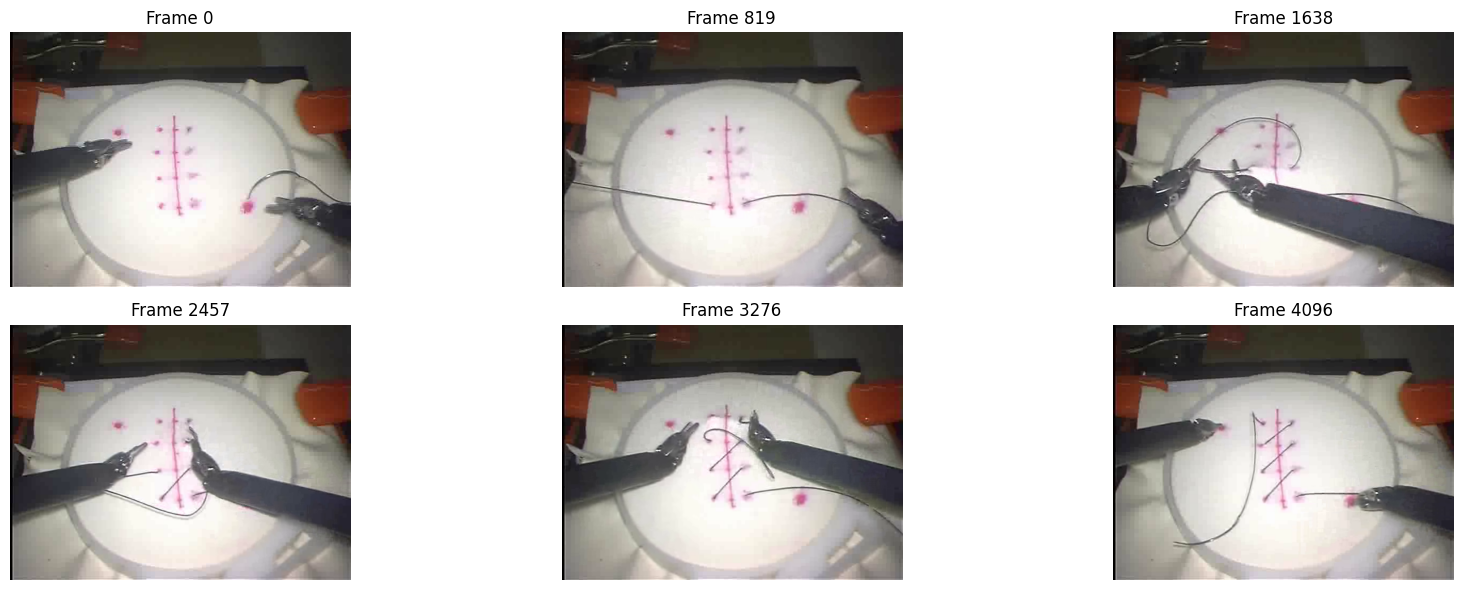

In [19]:
def get_video_info(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video: {video_path}")
    info = {
        "frame_count": int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
        "fps": float(cap.get(cv2.CAP_PROP_FPS)),
        "width": int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        "height": int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
        "duration_sec": int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) / max(float(cap.get(cv2.CAP_PROP_FPS)), 1e-6)
    }
    cap.release()
    return info

def read_frame_at(video_path, frame_idx):
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()
    if not ret:
        return None
    return frame

def show_sample_frames(video_path, n=6):
    info = get_video_info(video_path)
    total = info["frame_count"]
    frame_ids = np.linspace(0, max(total - 1, 0), n, dtype=int)

    plt.figure(figsize=(18, 3 * math.ceil(n / 3)))
    for i, fid in enumerate(frame_ids, 1):
        frame = read_frame_at(video_path, int(fid))
        if frame is None:
            continue
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.subplot(math.ceil(n / 3), 3, i)
        plt.imshow(rgb)
        plt.title(f"Frame {fid}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

video_info = get_video_info(VIDEO_PATH)
print(json.dumps(video_info, indent=2))
show_sample_frames(VIDEO_PATH, n=6)

## 2) Optional: save all frames
You do **not** need this for detection, but sometimes it is useful for debugging or manual annotation.

In [20]:
def extract_all_frames(video_path, out_dir, every_n=1, max_frames=None):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    saved = 0
    frame_idx = 0

    with tqdm(total=total, desc="Extracting all frames") as pbar:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if frame_idx % every_n == 0:
                out_path = out_dir / f"frame_{frame_idx:06d}.jpg"
                cv2.imwrite(str(out_path), frame)
                saved += 1
                if max_frames is not None and saved >= max_frames:
                    break

            frame_idx += 1
            pbar.update(1)

    cap.release()
    print(f"Saved {saved} frames to {out_dir}")

# Uncomment if you want all frames:
# extract_all_frames(VIDEO_PATH, FRAMES_DIR, every_n=SAVE_EVERY_NTH_FRAME, max_frames=MAX_FRAMES)

## 3) Detector models

### Recommended detector
Use **YOLO** with your own trained surgical weights.

Why YOLO here:
- fast frame-wise detection
- easy export of boxes and crops
- easy to retrain on custom suturing classes
- works well as stage 1 before temporal prediction

### Important note
A default COCO model (`yolov8n.pt`) is mainly for general objects.  
For **surgical instruments**, you will get much better results after training on your own labeled frames.

This notebook includes:
- YOLO inference code
- a **classical fallback detector**
- a clear place where you can later plug in **custom weights**

In [24]:
# Try importing ultralytics only if available
try:
    from ultralytics import YOLO
    ULTRALYTICS_AVAILABLE = True
except Exception as e:
    ULTRALYTICS_AVAILABLE = False
    print("Ultralytics not available right now. YOLO cells will fail unless installed.")
    print("Install with: pip install ultralytics")

In [23]:
!pip install -q ultralytics

In [25]:
def draw_boxes(frame, detections, color=(0, 255, 0), thickness=2):
    img = frame.copy()
    for det in detections:
        x1, y1, x2, y2 = map(int, det["bbox"])
        label = det.get("label", "obj")
        score = det.get("score", 0.0)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)
        text = f"{label} {score:.2f}"
        cv2.putText(img, text, (x1, max(20, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)
    return img

def clamp_box(x1, y1, x2, y2, w, h):
    x1 = max(0, min(x1, w - 1))
    y1 = max(0, min(y1, h - 1))
    x2 = max(0, min(x2, w - 1))
    y2 = max(0, min(y2, h - 1))
    return x1, y1, x2, y2

def box_area(box):
    x1, y1, x2, y2 = box
    return max(0, x2 - x1) * max(0, y2 - y1)

In [26]:
class YoloDetector:
    def __init__(self, weights="yolov8n.pt", conf=0.25, iou=0.45, imgsz=640, target_classes=None):
        if not ULTRALYTICS_AVAILABLE:
            raise ImportError("Ultralytics is not installed.")
        self.model = YOLO(weights)
        self.conf = conf
        self.iou = iou
        self.imgsz = imgsz
        self.target_classes = target_classes

    def predict(self, frame):
        results = self.model.predict(
            source=frame,
            conf=self.conf,
            iou=self.iou,
            imgsz=self.imgsz,
            classes=self.target_classes,
            verbose=False,
            device=0 if torch.cuda.is_available() else "cpu"
        )

        detections = []
        if len(results) == 0:
            return detections

        r = results[0]
        names = r.names if hasattr(r, "names") else {}

        if r.boxes is None or len(r.boxes) == 0:
            return detections

        boxes_xyxy = r.boxes.xyxy.detach().cpu().numpy()
        scores = r.boxes.conf.detach().cpu().numpy()
        classes = r.boxes.cls.detach().cpu().numpy().astype(int)

        for box, score, cls_id in zip(boxes_xyxy, scores, classes):
            x1, y1, x2, y2 = map(int, box.tolist())
            area = box_area((x1, y1, x2, y2))
            if area < MIN_BOX_AREA:
                continue
            detections.append({
                "bbox": [x1, y1, x2, y2],
                "score": float(score),
                "class_id": int(cls_id),
                "label": names.get(int(cls_id), str(cls_id))
            })
        return detections

### Classical fallback detector
This detector is useful when:
- you do not have trained weights yet
- you want to quickly extract activity-heavy frames
- you want a rough surgical work-region detector

It is **not as strong** as a trained YOLO model, but it is practical for bootstrapping.

In [27]:
class ClassicalMotionDetector:
    def __init__(self, blur_kernel=7, threshold_binary=25, min_area=1200):
        self.blur_kernel = blur_kernel
        self.threshold_binary = threshold_binary
        self.min_area = min_area
        self.bg_subtractor = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=25, detectShadows=False)

    def predict(self, frame):
        h, w = frame.shape[:2]

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = cv2.GaussianBlur(gray, (self.blur_kernel, self.blur_kernel), 0)

        fg_mask = self.bg_subtractor.apply(gray)
        _, fg_mask = cv2.threshold(fg_mask, 200, 255, cv2.THRESH_BINARY)

        kernel = np.ones((5, 5), np.uint8)
        fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_OPEN, kernel)
        fg_mask = cv2.morphologyEx(fg_mask, cv2.MORPH_DILATE, kernel)

        contours, _ = cv2.findContours(fg_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        detections = []
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < self.min_area:
                continue
            x, y, bw, bh = cv2.boundingRect(cnt)
            x1, y1, x2, y2 = clamp_box(x, y, x + bw, y + bh, w, h)
            detections.append({
                "bbox": [x1, y1, x2, y2],
                "score": 1.0,
                "class_id": 0,
                "label": "motion_roi"
            })
        return detections

## 4) Detection + save only detected frames

This is the main extraction step.

For each frame:
- run detector
- if detection exists:
  - save the **full frame**
  - save **cropped detections**
  - optionally save **annotated frame**
  - write metadata to JSON/CSV

This gives you clean reusable data for downstream training and later video generation.

In [28]:
def save_crop(frame, bbox, out_path):
    x1, y1, x2, y2 = map(int, bbox)
    crop = frame[y1:y2, x1:x2]
    if crop.size == 0:
        return False
    cv2.imwrite(str(out_path), crop)
    return True

def run_detection_and_save(
    video_path,
    detector,
    detected_frames_dir,
    crops_dir,
    annotated_dir,
    meta_dir,
    save_every_n=1,
    max_frames=None,
    save_full_frame_if_detected=True,
    save_crops_if_detected=True,
    save_annotated_frames=True
):
    detected_frames_dir = Path(detected_frames_dir)
    crops_dir = Path(crops_dir)
    annotated_dir = Path(annotated_dir)
    meta_dir = Path(meta_dir)

    metadata_records = []
    json_records = []

    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = float(cap.get(cv2.CAP_PROP_FPS))
    frame_idx = 0
    processed = 0
    saved_detected_frames = 0
    saved_crops = 0

    with tqdm(total=total, desc="Running detection") as pbar:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if frame_idx % save_every_n == 0:
                detections = detector.predict(frame)

                if len(detections) > 0:
                    frame_name = f"frame_{frame_idx:06d}.jpg"
                    frame_path = detected_frames_dir / frame_name
                    ann_path = annotated_dir / frame_name

                    if save_full_frame_if_detected:
                        cv2.imwrite(str(frame_path), frame)
                        saved_detected_frames += 1

                    if save_annotated_frames:
                        annotated = draw_boxes(frame, detections)
                        cv2.imwrite(str(ann_path), annotated)

                    for det_id, det in enumerate(detections):
                        crop_name = f"frame_{frame_idx:06d}_det_{det_id:02d}.jpg"
                        crop_path = crops_dir / crop_name
                        crop_saved = False

                        if save_crops_if_detected:
                            crop_saved = save_crop(frame, det["bbox"], crop_path)
                            if crop_saved:
                                saved_crops += 1

                        record = {
                            "frame_idx": frame_idx,
                            "timestamp_sec": frame_idx / max(fps, 1e-6),
                            "frame_file": str(frame_path) if save_full_frame_if_detected else None,
                            "annotated_file": str(ann_path) if save_annotated_frames else None,
                            "crop_file": str(crop_path) if crop_saved else None,
                            "x1": det["bbox"][0],
                            "y1": det["bbox"][1],
                            "x2": det["bbox"][2],
                            "y2": det["bbox"][3],
                            "score": det["score"],
                            "class_id": det["class_id"],
                            "label": det["label"]
                        }
                        metadata_records.append(record)

                    json_records.append({
                        "frame_idx": frame_idx,
                        "timestamp_sec": frame_idx / max(fps, 1e-6),
                        "detections": detections
                    })

                processed += 1
                if max_frames is not None and processed >= max_frames:
                    break

            frame_idx += 1
            pbar.update(1)

    cap.release()

    df = pd.DataFrame(metadata_records)
    csv_path = meta_dir / "detections.csv"
    json_path = meta_dir / "detections.json"

    df.to_csv(csv_path, index=False)
    with open(json_path, "w") as f:
        json.dump(json_records, f, indent=2)

    summary = {
        "processed_frames": processed,
        "saved_detected_frames": saved_detected_frames,
        "saved_crops": saved_crops,
        "detections_csv": str(csv_path),
        "detections_json": str(json_path),
    }

    with open(meta_dir / "summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    return df, summary

In [29]:
# Choose detector
if USE_YOLO and ULTRALYTICS_AVAILABLE:
    detector = YoloDetector(
        weights=YOLO_WEIGHTS,
        conf=YOLO_CONF,
        iou=YOLO_IOU,
        imgsz=YOLO_IMG_SIZE,
        target_classes=TARGET_CLASSES
    )
    print("Using YOLO detector with weights:", YOLO_WEIGHTS)
else:
    detector = ClassicalMotionDetector(
        blur_kernel=BLUR_KERNEL,
        threshold_binary=THRESHOLD_BINARY,
        min_area=MOTION_MIN_AREA
    )
    print("Using classical fallback detector")

detections_df, detection_summary = run_detection_and_save(
    video_path=VIDEO_PATH,
    detector=detector,
    detected_frames_dir=DETECTED_FRAMES_DIR,
    crops_dir=CROPS_DIR,
    annotated_dir=ANNOTATED_DIR,
    meta_dir=META_DIR,
    save_every_n=SAVE_EVERY_NTH_FRAME,
    max_frames=MAX_FRAMES,
    save_full_frame_if_detected=SAVE_FULL_FRAME_IF_DETECTED,
    save_crops_if_detected=SAVE_CROPS_IF_DETECTED,
    save_annotated_frames=SAVE_ANNOTATED_FRAMES
)

print(json.dumps(detection_summary, indent=2))
print(detections_df.head())

Using YOLO detector with weights: yolov8n.pt


Running detection:   0%|          | 0/4097 [00:00<?, ?it/s]

{
  "processed_frames": 4097,
  "saved_detected_frames": 2260,
  "saved_crops": 2795,
  "detections_csv": "suturing_detection_prediction_project/metadata/detections.csv",
  "detections_json": "suturing_detection_prediction_project/metadata/detections.json"
}
   frame_idx  timestamp_sec  \
0          3       0.100000   
1          6       0.200000   
2          8       0.266666   
3          8       0.266666   
4          9       0.300000   

                                          frame_file  \
0  suturing_detection_prediction_project/detected...   
1  suturing_detection_prediction_project/detected...   
2  suturing_detection_prediction_project/detected...   
3  suturing_detection_prediction_project/detected...   
4  suturing_detection_prediction_project/detected...   

                                      annotated_file  \
0  suturing_detection_prediction_project/annotate...   
1  suturing_detection_prediction_project/annotate...   
2  suturing_detection_prediction_project/annotate

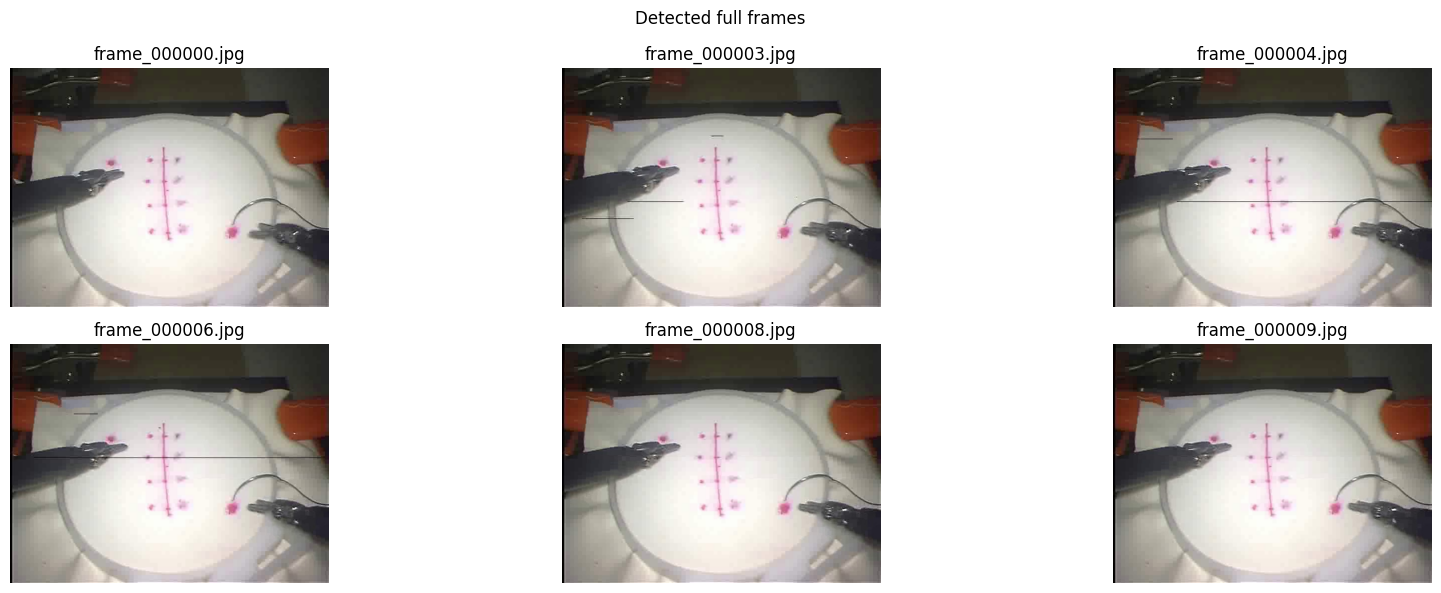

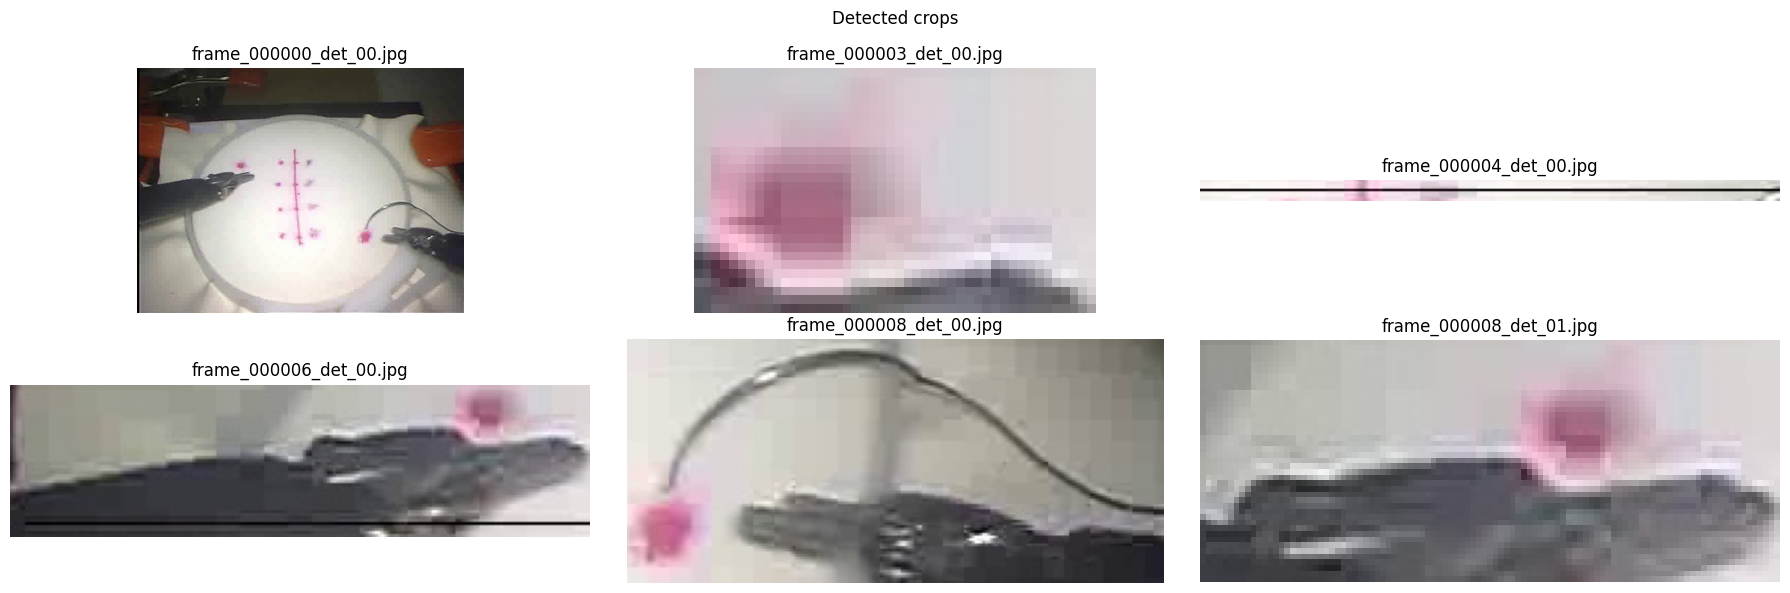

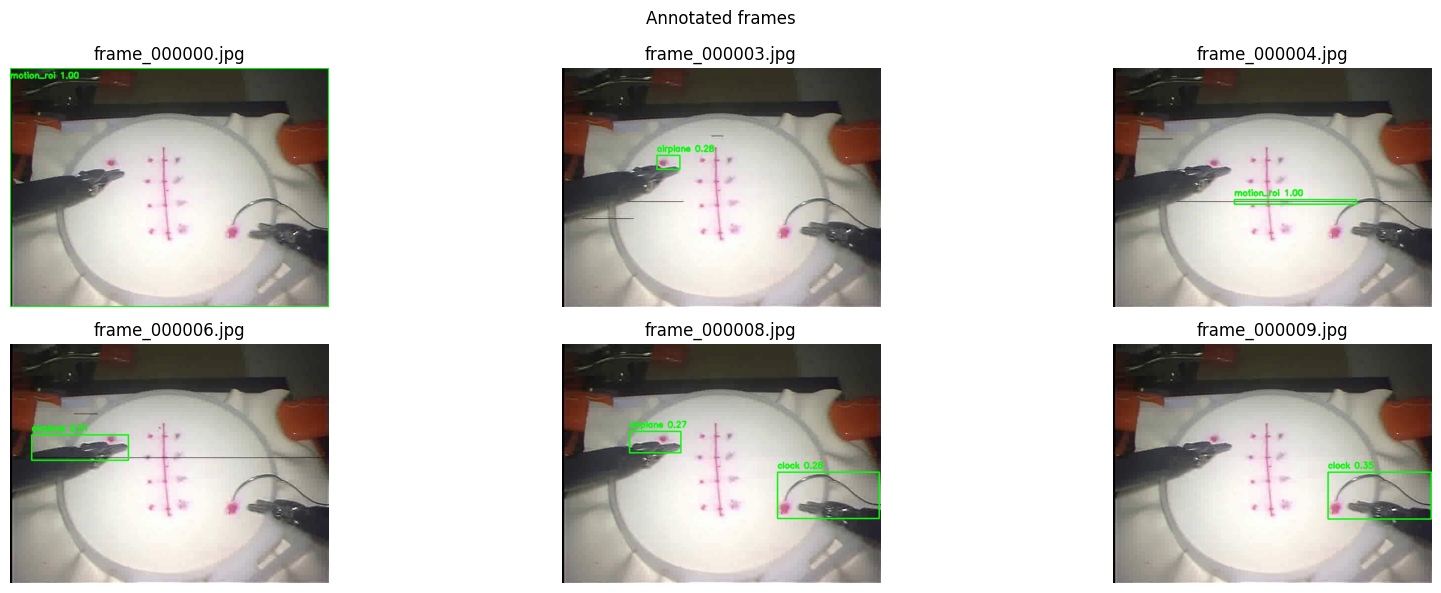

In [30]:
# Quick visualization of saved outputs
def show_saved_examples(image_dir, n=6, title="Examples"):
    image_dir = Path(image_dir)
    files = sorted(list(image_dir.glob("*.jpg")))[:n]
    if len(files) == 0:
        print("No files found in", image_dir)
        return

    plt.figure(figsize=(18, 3 * math.ceil(len(files) / 3)))
    for i, fp in enumerate(files, 1):
        img = cv2.imread(str(fp))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(math.ceil(len(files) / 3), 3, i)
        plt.imshow(img)
        plt.title(fp.name)
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_saved_examples(DETECTED_FRAMES_DIR, n=6, title="Detected full frames")
show_saved_examples(CROPS_DIR, n=6, title="Detected crops")
show_saved_examples(ANNOTATED_DIR, n=6, title="Annotated frames")

## 5) Make clip sequences from detected frames

Now we convert detected frames into short temporal clips such as:
- 16 frames per clip
- stride 8

These clips are what the **prediction model** will learn from later.

In [31]:
def build_clip_sequences_from_detected_frames(detected_frames_dir, clips_dir, seq_len=16, stride=8):
    detected_frames_dir = Path(detected_frames_dir)
    clips_dir = Path(clips_dir)
    clips_dir.mkdir(parents=True, exist_ok=True)

    frame_files = sorted(detected_frames_dir.glob("*.jpg"))
    if len(frame_files) < seq_len:
        print("Not enough detected frames to form even one clip.")
        return pd.DataFrame()

    records = []
    clip_idx = 0
    for start in range(0, len(frame_files) - seq_len + 1, stride):
        clip_files = frame_files[start:start + seq_len]
        clip_id = f"clip_{clip_idx:05d}"
        clip_folder = clips_dir / clip_id
        clip_folder.mkdir(parents=True, exist_ok=True)

        for j, src in enumerate(clip_files):
            dst = clip_folder / f"{j:03d}.jpg"
            if not dst.exists():
                shutil.copy2(src, dst)

        records.append({
            "clip_id": clip_id,
            "clip_dir": str(clip_folder),
            "num_frames": len(clip_files),
            "start_frame_file": clip_files[0].name,
            "end_frame_file": clip_files[-1].name
        })
        clip_idx += 1

    clips_df = pd.DataFrame(records)
    clips_df.to_csv(META_DIR / "clip_sequences.csv", index=False)
    print(f"Built {len(clips_df)} clips")
    return clips_df

clips_df = build_clip_sequences_from_detected_frames(
    detected_frames_dir=DETECTED_FRAMES_DIR,
    clips_dir=CLIPS_DIR,
    seq_len=SEQ_LEN,
    stride=SEQ_STRIDE
)
clips_df.head()

Built 442 clips


,clip_id,clip_dir,num_frames,start_frame_file,end_frame_file
0,clip_00000,suturing_detection_prediction_project/clip_seq...,16,frame_000000.jpg,frame_000023.jpg
1,clip_00001,suturing_detection_prediction_project/clip_seq...,16,frame_000014.jpg,frame_000036.jpg
2,clip_00002,suturing_detection_prediction_project/clip_seq...,16,frame_000025.jpg,frame_000056.jpg
3,clip_00003,suturing_detection_prediction_project/clip_seq...,16,frame_000048.jpg,frame_000069.jpg
4,clip_00004,suturing_detection_prediction_project/clip_seq...,16,frame_000059.jpg,frame_000083.jpg


## 6) Detailed prediction model

This section gives you a **real temporal model** that can be used after detection.

### Model structure
We use:

**Frame encoder (CNN backbone) → BiLSTM → Attention pooling → Classifier**

Why this works well:
- the detector isolates the relevant regions/frames
- the CNN learns spatial features per frame
- the BiLSTM learns motion/temporal dynamics
- attention focuses on the most informative time steps

This can be used for:
- phase classification
- gesture/action recognition
- binary outcome prediction
- multi-class skill/event prediction

You can later replace the backbone with:
- ResNet50
- EfficientNet
- ConvNeXt
- ViT
- TimeSformer / Video Swin (more advanced)

In [32]:
# Basic image preprocessing without torchvision dependency
def resize_and_normalize_bgr(frame, img_size=224):
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame = cv2.resize(frame, (img_size, img_size))
    frame = frame.astype(np.float32) / 255.0

    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    frame = (frame - mean) / std

    # HWC -> CHW
    frame = np.transpose(frame, (2, 0, 1))
    return torch.tensor(frame, dtype=torch.float32)

class ClipSequenceDataset(Dataset):
    def __init__(self, clips_df, img_size=224, labels_csv=None):
        self.clips_df = clips_df.reset_index(drop=True)
        self.img_size = img_size

        self.label_map = {}
        if labels_csv is not None and os.path.exists(labels_csv):
            labels_df = pd.read_csv(labels_csv)
            self.label_map = dict(zip(labels_df["clip_id"], labels_df["label"]))

    def __len__(self):
        return len(self.clips_df)

    def __getitem__(self, idx):
        row = self.clips_df.iloc[idx]
        clip_dir = Path(row["clip_dir"])
        frame_files = sorted(list(clip_dir.glob("*.jpg")))

        frames = []
        for fp in frame_files:
            img = cv2.imread(str(fp))
            img = resize_and_normalize_bgr(img, self.img_size)
            frames.append(img)

        clip_tensor = torch.stack(frames, dim=0)  # [T, C, H, W]
        label = self.label_map.get(row["clip_id"], -1)

        return {
            "clip": clip_tensor,
            "label": torch.tensor(label, dtype=torch.long),
            "clip_id": row["clip_id"]
        }

In [33]:
# Simple CNN encoder + BiLSTM + Attention
class SmallCNNEncoder(nn.Module):
    def __init__(self, out_dim=256):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.proj = nn.Linear(256, out_dim)

    def forward(self, x):
        # x: [B*T, C, H, W]
        x = self.features(x)
        x = x.flatten(1)
        x = self.proj(x)
        return x

class TemporalAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(dim, dim),
            nn.Tanh(),
            nn.Linear(dim, 1)
        )

    def forward(self, x):
        # x: [B, T, D]
        scores = self.attn(x)                   # [B, T, 1]
        weights = torch.softmax(scores, dim=1)  # [B, T, 1]
        context = (x * weights).sum(dim=1)      # [B, D]
        return context, weights

class DetectionToPredictionModel(nn.Module):
    def __init__(self, cnn_out_dim=256, lstm_hidden=256, num_classes=3, dropout=0.3):
        super().__init__()
        self.encoder = SmallCNNEncoder(out_dim=cnn_out_dim)
        self.temporal = nn.LSTM(
            input_size=cnn_out_dim,
            hidden_size=lstm_hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )
        self.attn = TemporalAttention(dim=lstm_hidden * 2)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden * 2, lstm_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden, num_classes)
        )

    def forward(self, clip):
        # clip: [B, T, C, H, W]
        B, T, C, H, W = clip.shape
        x = clip.view(B * T, C, H, W)
        x = self.encoder(x)           # [B*T, D]
        x = x.view(B, T, -1)          # [B, T, D]
        x, _ = self.temporal(x)       # [B, T, 2H]
        context, attn_weights = self.attn(x)
        logits = self.classifier(context)
        return logits, attn_weights

In [34]:
# Create dataset and inspect one batch
if len(clips_df) > 0:
    dataset = ClipSequenceDataset(clips_df, img_size=IMG_SIZE, labels_csv=CLIP_LABELS_CSV)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

    batch = next(iter(loader))
    print("Clip batch shape:", batch["clip"].shape)
    print("Label batch shape:", batch["label"].shape)

    model = DetectionToPredictionModel(num_classes=NUM_CLASSES).to(DEVICE)
    with torch.no_grad():
        logits, attn = model(batch["clip"].to(DEVICE))
    print("Logits shape:", logits.shape)
    print("Attention shape:", attn.shape)
else:
    print("No clips available yet.")

Clip batch shape: torch.Size([4, 16, 3, 224, 224])
Label batch shape: torch.Size([4])
Logits shape: torch.Size([4, 3])
Attention shape: torch.Size([4, 16, 1])


## 7) Training loop for prediction

This trains the temporal model **after** clip creation.

### Label file format
Create a CSV like this:

| clip_id | label |
|---|---|
| clip_00000 | 0 |
| clip_00001 | 2 |
| clip_00002 | 1 |

Where `label` is your task label, for example:
- 0 = no valid action
- 1 = needle insertion
- 2 = knot tying

or anything else needed for your research.

In [35]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for batch in tqdm(loader, desc="Train", leave=False):
        clips = batch["clip"].to(device)
        labels = batch["label"].to(device)

        # Ignore unlabeled samples
        valid_mask = labels >= 0
        if valid_mask.sum() == 0:
            continue
        clips = clips[valid_mask]
        labels = labels[valid_mask]

        optimizer.zero_grad()
        logits, _ = model(clips)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_count += labels.size(0)

    avg_loss = total_loss / max(total_count, 1)
    avg_acc = total_correct / max(total_count, 1)
    return avg_loss, avg_acc

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for batch in tqdm(loader, desc="Eval", leave=False):
        clips = batch["clip"].to(device)
        labels = batch["label"].to(device)

        valid_mask = labels >= 0
        if valid_mask.sum() == 0:
            continue
        clips = clips[valid_mask]
        labels = labels[valid_mask]

        logits, _ = model(clips)
        loss = criterion(logits, labels)

        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_count += labels.size(0)

    avg_loss = total_loss / max(total_count, 1)
    avg_acc = total_correct / max(total_count, 1)
    return avg_loss, avg_acc

In [36]:
# Train only if labels are available
if CLIP_LABELS_CSV is not None and os.path.exists(CLIP_LABELS_CSV) and len(clips_df) > 1:
    full_dataset = ClipSequenceDataset(clips_df, img_size=IMG_SIZE, labels_csv=CLIP_LABELS_CSV)

    # Simple split
    indices = list(range(len(full_dataset)))
    random.shuffle(indices)
    split = int(0.8 * len(indices))
    train_idx, val_idx = indices[:split], indices[split:]

    train_subset = torch.utils.data.Subset(full_dataset, train_idx)
    val_subset = torch.utils.data.Subset(full_dataset, val_idx)

    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = DetectionToPredictionModel(num_classes=NUM_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    best_val_acc = 0.0
    history = []

    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc
        })

        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
              f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), MODELS_DIR / "best_temporal_model.pt")

    pd.DataFrame(history).to_csv(META_DIR / "training_history.csv", index=False)
    print("Saved best model to:", MODELS_DIR / "best_temporal_model.pt")
else:
    print("Training skipped because clip label CSV is missing or there are not enough clips.")

Training skipped because clip label CSV is missing or there are not enough clips.


In [39]:
@torch.no_grad()
def predict_on_clips(model, clips_df, img_size=224, model_path=None):
    ds = ClipSequenceDataset(clips_df, img_size=img_size, labels_csv=None)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    if model_path is not None:
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()

    records = []
    for batch in tqdm(dl, desc="Predict clips"):
        clips = batch["clip"].to(DEVICE)
        clip_ids = batch["clip_id"]
        logits, attn = model(clips)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        for i in range(len(clip_ids)):
            row = {
                "clip_id": clip_ids[i],
                "pred_label": int(preds[i].item())
            }
            for c in range(probs.shape[1]):
                row[f"prob_class_{c}"] = float(probs[i, c].item())
            records.append(row)

    pred_df = pd.DataFrame(records)
    pred_df.to_csv(META_DIR / "clip_predictions.csv", index=False)
    return pred_df

# Run prediction on the clips we just built
model = DetectionToPredictionModel(num_classes=NUM_CLASSES).to(DEVICE)
pred_df = predict_on_clips(model, clips_df, img_size=IMG_SIZE)
display(pred_df.head())

Predict clips:   0%|          | 0/111 [00:00<?, ?it/s]

,clip_id,pred_label,prob_class_0,prob_class_1,prob_class_2
0,clip_00000,2,0.325487,0.327563,0.34695
1,clip_00001,2,0.325487,0.327563,0.34695
2,clip_00002,2,0.325487,0.327563,0.34695
3,clip_00003,2,0.325488,0.327562,0.34695
4,clip_00004,2,0.325488,0.327562,0.34695


In [40]:
def zip_folder(folder_path, zip_path):
    folder_path = Path(folder_path)
    zip_path = Path(zip_path)
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for file in folder_path.rglob("*"):
            if file.is_file():
                zf.write(file, arcname=file.relative_to(folder_path))
    return zip_path

# Creating ZIP files for download
detected_frames_zip = EXPORTS_DIR / "detected_frames.zip"
crops_zip = EXPORTS_DIR / "detected_crops.zip"
metadata_zip = EXPORTS_DIR / "metadata.zip"

if DETECTED_FRAMES_DIR.exists():
    zip_folder(DETECTED_FRAMES_DIR, detected_frames_zip)
if CROPS_DIR.exists():
    zip_folder(CROPS_DIR, crops_zip)
if META_DIR.exists():
    zip_folder(META_DIR, metadata_zip)

print("ZIP files created in:", EXPORTS_DIR)
print(f"- {detected_frames_zip.name}")
print(f"- {crops_zip.name}")
print(f"- {metadata_zip.name}")

ZIP files created in: suturing_detection_prediction_project/exports
- detected_frames.zip
- detected_crops.zip
- metadata.zip


## 8) Prediction inference on clips

This cell loads the trained temporal model and predicts labels on each detected clip.

In [41]:
@torch.no_grad()
def predict_on_clips(model, clips_df, img_size=224, model_path=None):
    ds = ClipSequenceDataset(clips_df, img_size=img_size, labels_csv=None)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    if model_path is not None:
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()

    records = []
    for batch in tqdm(dl, desc="Predict clips"):
        clips = batch["clip"].to(DEVICE)
        clip_ids = batch["clip_id"]
        logits, attn = model(clips)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        for i in range(len(clip_ids)):
            row = {
                "clip_id": clip_ids[i],
                "pred_label": int(preds[i].item())
            }
            for c in range(probs.shape[1]):
                row[f"prob_class_{c}"] = float(probs[i, c].item())
            records.append(row)

    pred_df = pd.DataFrame(records)
    pred_df.to_csv(META_DIR / "clip_predictions.csv", index=False)
    return pred_df

# Example usage after training:
# model = DetectionToPredictionModel(num_classes=NUM_CLASSES).to(DEVICE)
# pred_df = predict_on_clips(model, clips_df, img_size=IMG_SIZE, model_path=MODELS_DIR / "best_temporal_model.pt")
# pred_df.head()

## 9) Export only the detected frames for download

This is the part you specifically asked for.

It creates ZIP files for:
- detected full frames
- detected crops
- annotated frames
- metadata

You can then download and reuse them later for:
- annotation
- training
- making videos
- report generation

In [42]:
def zip_folder(folder_path, zip_path):
    folder_path = Path(folder_path)
    zip_path = Path(zip_path)
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for file in folder_path.rglob("*"):
            if file.is_file():
                zf.write(file, arcname=file.relative_to(folder_path))
    return zip_path

detected_frames_zip = EXPORTS_DIR / "detected_frames.zip"
crops_zip = EXPORTS_DIR / "detected_crops.zip"
annotated_zip = EXPORTS_DIR / "annotated_frames.zip"
metadata_zip = EXPORTS_DIR / "metadata.zip"

if DETECTED_FRAMES_DIR.exists():
    zip_folder(DETECTED_FRAMES_DIR, detected_frames_zip)
if CROPS_DIR.exists():
    zip_folder(CROPS_DIR, crops_zip)
if ANNOTATED_DIR.exists():
    zip_folder(ANNOTATED_DIR, annotated_zip)
if META_DIR.exists():
    zip_folder(META_DIR, metadata_zip)

print("Created:")
for p in [detected_frames_zip, crops_zip, annotated_zip, metadata_zip]:
    print("-", p.resolve(), "| exists:", p.exists())

Created:
- /content/suturing_detection_prediction_project/exports/detected_frames.zip | exists: True
- /content/suturing_detection_prediction_project/exports/detected_crops.zip | exists: True
- /content/suturing_detection_prediction_project/exports/annotated_frames.zip | exists: True
- /content/suturing_detection_prediction_project/exports/metadata.zip | exists: True


## 10) Rebuild a video from detected frames later

If later you want to make a video using only the detected frames, use this cell.

In [43]:
def make_video_from_frames(frame_dir, out_path, fps=10):
    frame_dir = Path(frame_dir)
    frame_files = sorted(frame_dir.glob("*.jpg"))
    if len(frame_files) == 0:
        raise ValueError(f"No frames found in {frame_dir}")

    first = cv2.imread(str(frame_files[0]))
    h, w = first.shape[:2]

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(out_path), fourcc, fps, (w, h))

    for fp in tqdm(frame_files, desc=f"Writing video: {out_path.name}"):
        frame = cv2.imread(str(fp))
        writer.write(frame)
    writer.release()
    return out_path

detected_video_path = EXPORTS_DIR / "detected_only_video.mp4"
if len(list(DETECTED_FRAMES_DIR.glob("*.jpg"))) > 0:
    make_video_from_frames(DETECTED_FRAMES_DIR, detected_video_path, fps=10)
    print("Saved video to:", detected_video_path.resolve())
else:
    print("No detected frames found yet.")

Writing video: detected_only_video.mp4:   0%|          | 0/3547 [00:00<?, ?it/s]

Saved video to: /content/suturing_detection_prediction_project/exports/detected_only_video.mp4


## 11) How to train a proper custom YOLO detector on this project

For real suturing detection, follow this flow:

1. Extract frames from multiple videos  
2. Label them in:
   - CVAT
   - Label Studio
   - Roboflow
3. Create classes such as:
   - needle_driver
   - forceps
   - thread
   - needle
   - left_tool
   - right_tool
   - tissue_region
4. Train YOLO on those labels  
5. Replace `YOLO_WEIGHTS = "yolov8n.pt"` with your trained `best.pt`  
6. Re-run this notebook to save only true surgical detections  
7. Build clip labels and train the temporal predictor

### Example YOLO training command
Run this separately after preparing a dataset YAML:

```python
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
model.train(
    data="suturing_dataset.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0
)
```

Then use:

```python
YOLO_WEIGHTS = "runs/detect/train/weights/best.pt"
```

## 12) Recommended research-grade upgrade path

If you want stronger performance later, this is a solid progression:

### Detector
- YOLOv8 / YOLO11 custom-trained
- RT-DETR custom-trained
- Mask R-CNN / YOLO-seg if you need masks

### Temporal predictor
- CNN + BiLSTM + Attention  ← already included here
- CNN + Transformer Encoder
- TimeSformer
- Video Swin Transformer
- X3D / SlowFast

### Better supervision ideas
- phase label per clip
- gesture label per clip
- instrument presence label
- success/failure label
- skill score regression
- future step prediction

### Useful saved outputs from this notebook
- full detected frames
- detection crops
- detection CSV / JSON
- clip sequences
- prediction CSV
- video made from detected frames

## 13) Final notes

This notebook is designed to be **practical first**:
- it works as a starting point immediately
- it is easy to adapt
- it supports both bootstrapping and full custom training

For your exact suturing use case, the best real-world pipeline is:

**Custom surgical detector → save detected frames → build clips → temporal predictor → export detected-only video**

That is exactly what this notebook is structured to do.